# Assignment 3
## Jackie McGinley
### February 12, 2026

#### Configure

In [109]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

#### Load Proper Libraries

In [110]:
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


# Load in Database

In [111]:
%sql sqlite:///airline_industry.db

#### Q1. How many records are in each table in the database?

## Table Names

In [112]:
%%sql
select name
from sqlite_master
where  type = 'table';


 * sqlite:///airline_industry.db
Done.


name
planes
weather
airports
airlines
flights


## Count for Planes

In [113]:
%%sql
select 
    count(*)
from 
    planes

 * sqlite:///airline_industry.db
Done.


count(*)
3322


## Count for Weather

In [114]:
%%sql
select
    count(*)
from
    weather

 * sqlite:///airline_industry.db
Done.


count(*)
26115


## Count for Airports

In [115]:
%%sql
select
    count(*)
from
    airports

 * sqlite:///airline_industry.db
Done.


count(*)
1458


## Count for Airlines

In [116]:
%%sql
select
    count(*)
from
    airlines

 * sqlite:///airline_industry.db
Done.


count(*)
16


## Count for Flights

In [117]:
%%sql
select
    count(*)
from
    flights

 * sqlite:///airline_industry.db
Done.


count(*)
336776


#### Q2. Did any flights depart and arrive exactly on time?

In [118]:
%%sql
select 
     *
from
    flights
limit
    5

 * sqlite:///airline_industry.db
Done.


field1,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
1,2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2,2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
3,2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
4,2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
5,2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00


In [119]:
%%sql
select count(*) as 'Flights On Time'
from 
    flights
where
    dep_time = sched_dep_time
and 
    arr_time = sched_arr_time

 * sqlite:///airline_industry.db
Done.


Flights On Time
347


### Yes, 347 flights departed and arrived on time

#### Q3. What is the mean arrival delay among flights?


In [120]:
%%sql
select 
    avg(arr_delay) as 'Average Arrival Delay'
from 
    flights


 * sqlite:///airline_industry.db
Done.


Average Arrival Delay
6.702300639000404


#### Q4. How many flights had above average arrival delays?

In [121]:
%%sql
select count(*) as 'Number of Flights'
from
    flights
having arr_delay > avg(arr_delay)

 * sqlite:///airline_industry.db
Done.


Number of Flights
336776


#### Q5. What is the relationship between temperature and wind speed? Do changes in the mean temperature throughout the year (by month) move reflect changes in mean wind speed?

In [122]:
%%sql
select *
from 
    weather
limit 5

 * sqlite:///airline_industry.db
Done.


field1,origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
1,EWR,2013,1,1,1,39.02,26.06,59.37,270,10.35702,NA,0,1012,10,2013-01-01 01:00:00
2,EWR,2013,1,1,2,39.02,26.96,61.63,250,8.05546,NA,0,1012.3,10,2013-01-01 02:00:00
3,EWR,2013,1,1,3,39.02,28.04,64.43,240,11.5078,NA,0,1012.5,10,2013-01-01 03:00:00
4,EWR,2013,1,1,4,39.92,28.04,62.21,250,12.65858,NA,0,1012.2,10,2013-01-01 04:00:00
5,EWR,2013,1,1,5,39.02,28.04,64.43,260,12.65858,NA,0,1011.9,10,2013-01-01 05:00:00


In [123]:
%%sql
select 
    year,
    month,
    avg(temp),
    avg(wind_speed)
from
    weather
group by
    year,
    month

 * sqlite:///airline_industry.db
Done.


year,month,avg(temp),avg(wind_speed)
2013,1,35.63566037735849,11.18365846361186
2013,2,34.27059701492537,12.67403823880597
2013,3,39.88007184553211,12.923150884598114
2013,4,51.74564150069477,11.098444261232052
2013,5,61.795,9.516620627240142
2013,6,72.184,10.26325274074074
2013,7,80.06622082585278,9.57347724416517
2013,8,74.43487595850247,8.611903915200722
2013,9,67.37129226493747,8.906685409911997
2013,10,60.07113019891501,9.702032649186256


#### Q6. Print the first 5 rows of flights and airlines. Does the flights table contain the full name of the airline? If so, print them. If not, write a query to return the first 10 records in the flights data with the following columns: the origin, destination, carrier, flight number, and full name of the airline for each flight in a single table.

In [124]:
%%sql
select *
from
    flights
limit 5


 * sqlite:///airline_industry.db
Done.


field1,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
1,2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2,2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
3,2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
4,2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
5,2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00


In [125]:
%%sql
select * 
from
    airlines
limit 5

 * sqlite:///airline_industry.db
Done.


field1,carrier,name
1,9E,Endeavor Air Inc.
2,AA,American Airlines Inc.
3,AS,Alaska Airlines Inc.
4,B6,JetBlue Airways
5,DL,Delta Air Lines Inc.


### No, the flight table does not containt he full name of the airline

In [126]:
%%sql
select
    f.origin,
    f.dest,
    f.carrier,
    f.flight,
    a.name
from
    flights f
left join airlines a
    on f.carrier = a.carrier
limit 10

 * sqlite:///airline_industry.db
Done.


origin,dest,carrier,flight,name
EWR,IAH,UA,1545,United Air Lines Inc.
LGA,IAH,UA,1714,United Air Lines Inc.
JFK,MIA,AA,1141,American Airlines Inc.
JFK,BQN,B6,725,JetBlue Airways
LGA,ATL,DL,461,Delta Air Lines Inc.
EWR,ORD,UA,1696,United Air Lines Inc.
EWR,FLL,B6,507,JetBlue Airways
LGA,IAD,EV,5708,ExpressJet Airlines Inc.
JFK,MCO,B6,79,JetBlue Airways
LGA,ORD,AA,301,American Airlines Inc.


#### Q7. Your supervisor is interested in the airlines that offer the most flights in peak periods. Write a query that returns the number of flights each airline operates in December. The results should be a single table that contains five columns: carrier, month, name, and num_flights. The results should be limited to 10 and shown in descending order by number of flights.

In [127]:
%%sql
select
    f.carrier,
    month,
    name,
    count(*) as num_flights
from
    flights f
left join airlines a
    on f.carrier = a.carrier
where
    month = 12
group by
    f.carrier,
    month,
    name
order by
    num_flights DESC
limit 10

 * sqlite:///airline_industry.db
Done.


carrier,month,name,num_flights
UA,12,United Air Lines Inc.,4931
B6,12,JetBlue Airways,4741
EV,12,ExpressJet Airlines Inc.,4307
DL,12,Delta Air Lines Inc.,4093
AA,12,American Airlines Inc.,2705
MQ,12,Envoy Air,2139
9E,12,Endeavor Air Inc.,1633
US,12,US Airways Inc.,1605
WN,12,Southwest Airlines Co.,1099
VX,12,Virgin America,476


#### Q8. Use pandas to connect to the database. Define a function that takes one argument--month_num--called num_flights_fun that uses pandas' `.read_sql_query()` and runs a query that returns the number of flights each airline operates in whatever month is specified in the function call. The result should be returned as a pandas dataframe that contains five columns: carrier, month, name, and num_flights.

In [128]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("airline_industry.db")

In [129]:
def num_flights_fun(month_num):
    """
    month_num : int
        Month number (1–12)
    
    pandas.DataFrame
        Columns: carrier, month, name, num_flights
    """
    query = """
        select
            f.carrier,
            f.month,
            a.name,
            count(*) AS num_flights
        from 
            flights f
        join 
            airlines a
            on f.carrier = a.carrier
        where 
            f.month = ?
        group by 
            f.carrier, f.month, a.name
        order by
            num_flights DESC;
    """
    
    df = pd.read_sql_query(query, conn, params=(month_num,))
    return df

In [130]:
num_flights_fun(7)

,carrier,month,name,num_flights
0,UA,7,United Air Lines Inc.,5066
1,B6,7,JetBlue Airways,4984
2,EV,7,ExpressJet Airlines Inc.,4641
3,DL,7,Delta Air Lines Inc.,4251
4,AA,7,American Airlines Inc.,2882
5,MQ,7,Envoy Air,2261
6,US,7,US Airways Inc.,1786
7,9E,7,Endeavor Air Inc.,1494
8,WN,7,Southwest Airlines Co.,1076
9,VX,7,Virgin America,489


#### Q9. Test your function to ensure it works. Create a new dataframe called sept that contains the results with only records from September and a dataframe called jan that contains the results with only records from January. The only change you should make to get the results is adjusting the value of the input parameter you are passing in the function call in num_flights_fun. Print out the last five rows of sept and jan.

In [131]:
sept = num_flights_fun(9)
sept.tail()

,carrier,month,name,num_flights
11,AS,9,Alaska Airlines Inc.,60
12,F9,9,Frontier Airlines Inc.,58
13,YV,9,Mesa Airlines Inc.,42
14,HA,9,Hawaiian Airlines Inc.,25
15,OO,9,SkyWest Airlines Inc.,20


In [132]:
jan = num_flights_fun(1)
jan.tail()

,carrier,month,name,num_flights
11,AS,1,Alaska Airlines Inc.,62
12,F9,1,Frontier Airlines Inc.,59
13,YV,1,Mesa Airlines Inc.,46
14,HA,1,Hawaiian Airlines Inc.,31
15,OO,1,SkyWest Airlines Inc.,1


#### Q10. Using sept and jan, print the top five airlines with the greatest number of flights in September and in January, in descending order. Are the top five airlines the same in September and January? If so, what are the airlines? If not, which airlines differ from September to January?

In [133]:
top5_sept = (
    sept.sort_values("num_flights", ascending=False)
        .head(5)
)

top5_sept

,carrier,month,name,num_flights
0,EV,9,ExpressJet Airlines Inc.,4725
1,UA,9,United Air Lines Inc.,4694
2,B6,9,JetBlue Airways,4291
3,DL,9,Delta Air Lines Inc.,3883
4,AA,9,American Airlines Inc.,2614


In [134]:
top5_jan = (
    jan.sort_values("num_flights", ascending=False)
        .head(5)
)

top5_jan

,carrier,month,name,num_flights
0,UA,1,United Air Lines Inc.,4637
1,B6,1,JetBlue Airways,4427
2,EV,1,ExpressJet Airlines Inc.,4171
3,DL,1,Delta Air Lines Inc.,3690
4,AA,1,American Airlines Inc.,2794


In [135]:
sept_airlines = set(top5_sept["name"])
jan_airlines = set(top5_jan["name"])

sept_airlines == jan_airlines

True

### Airlines in the top five in September and January are United Air Lines, JetBlue Airways, ExpressJet Airlines, Delta Air Lines, American Airlines

#### Q11. Create a new function using pandas called num_flights_fun_all that runs the same query as above but returns the records for all months. The function should not take any arguments.

In [136]:
def num_flights_fun_all():
    """
    pandas.DataFrame
        Columns: carrier, month, name, num_flights
    """
    
    query = """
        SELECT
            f.carrier,
            f.month,
            a.name,
            count(*) AS num_flights
        from 
            flights f
        join 
            airlines a
            on f.carrier = a.carrier
        group by f.carrier, f.month, a.name
        order by f.month, num_flights DESC;
    """
    
    df = pd.read_sql_query(query, conn)
    return df

In [137]:
all_months = num_flights_fun_all()
all_months

,carrier,month,name,num_flights
0,UA,1,United Air Lines Inc.,4637
1,B6,1,JetBlue Airways,4427
2,EV,1,ExpressJet Airlines Inc.,4171
3,DL,1,Delta Air Lines Inc.,3690
4,AA,1,American Airlines Inc.,2794
...,...,...,...,...
180,FL,12,AirTran Airways Corporation,213
181,F9,12,Frontier Airlines Inc.,61
182,AS,12,Alaska Airlines Inc.,54
183,YV,12,Mesa Airlines Inc.,50


#### Q12. Use num_flights_fun_all to create a dataframe called months_df. The dataframe should have carrier, month, name, and num_flights columns and contain the number of flights that each airline made in each month. Show the first 15 lines of the dataframe to ensure the results are correct.

In [138]:
months_df = num_flights_fun_all()
months_df.head(15)

,carrier,month,name,num_flights
0,UA,1,United Air Lines Inc.,4637
1,B6,1,JetBlue Airways,4427
2,EV,1,ExpressJet Airlines Inc.,4171
3,DL,1,Delta Air Lines Inc.,3690
4,AA,1,American Airlines Inc.,2794
5,MQ,1,Envoy Air,2271
6,US,1,US Airways Inc.,1602
7,9E,1,Endeavor Air Inc.,1573
8,WN,1,Southwest Airlines Co.,996
9,FL,1,AirTran Airways Corporation,328


#### Q13. Use months_df to plot the number of flights each airline made for each month using altair, plotly, or seaborn.

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

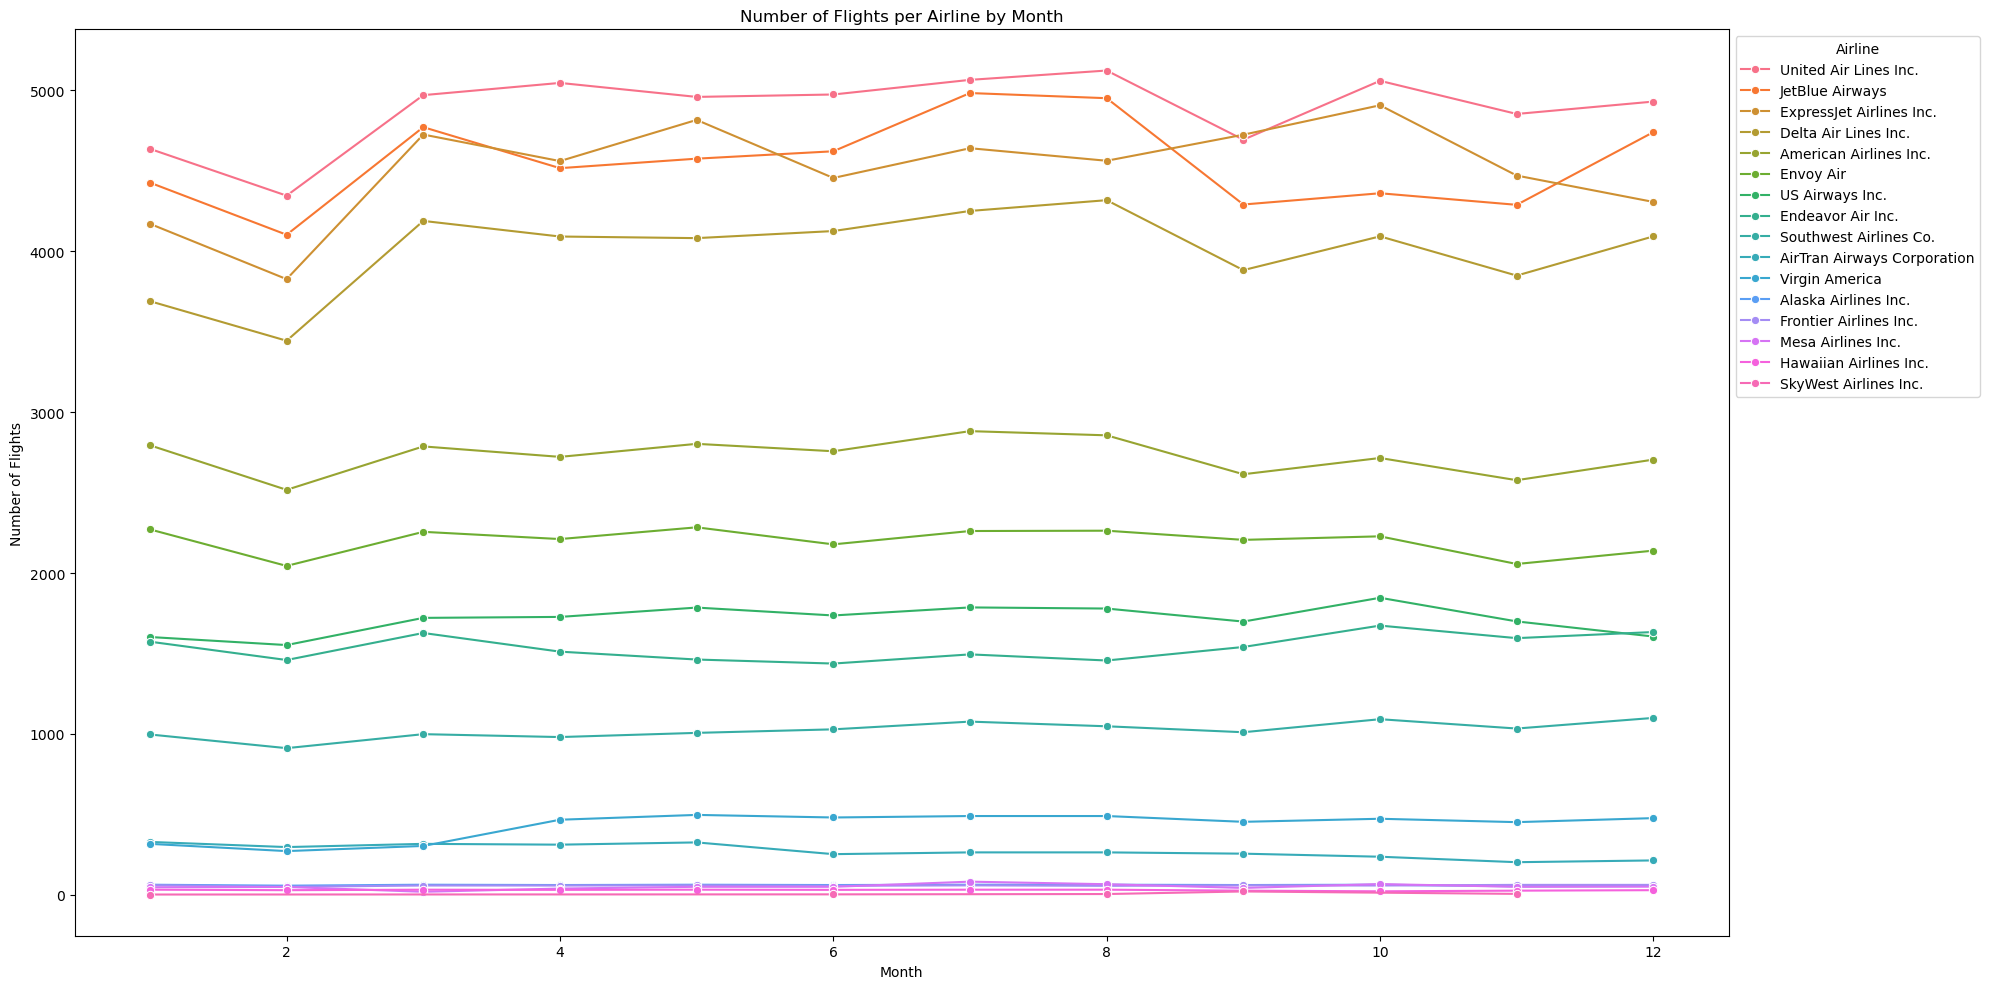

In [140]:
plt.figure(figsize=(20, 10))

sns.lineplot(
    data=months_df,
    x="month",
    y="num_flights",
    hue="name",
    marker="o"
)

plt.title("Number of Flights per Airline by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.legend(title="Airline", bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### Q14. Write a query that returns the each airlines' mean arrival delay across all of its flights. The result should have two columns: mean_delay and the full name of the airline. Which airline has the highest average delay?

In [141]:
%%sql
select
    a.name,
    round(avg(f.arr_delay), 2)  as mean_delay
from
    flights f
join
    airlines a
    on f.carrier = a.carrier
where f.arr_delay is not null
group by a.name
order by mean_delay DESC

 * sqlite:///airline_industry.db
Done.


name,mean_delay
Frontier Airlines Inc.,21.79
AirTran Airways Corporation,19.59
ExpressJet Airlines Inc.,14.9
Mesa Airlines Inc.,14.08
SkyWest Airlines Inc.,10.81
Envoy Air,10.22
Southwest Airlines Co.,9.47
JetBlue Airways,9.36
Endeavor Air Inc.,6.91
United Air Lines Inc.,3.5


In [142]:
%%sql
select
    a.name,
    round(avg(f.arr_delay), 2)  as mean_delay
from
    flights f
join
    airlines a
    on f.carrier = a.carrier
where f.arr_delay is not null
group by a.name
order by mean_delay DESC
limit 1

 * sqlite:///airline_industry.db
Done.


name,mean_delay
Frontier Airlines Inc.,21.79


#### Q15. Use pandas to query the data and return a dataframe to plot the data. Use either altair, seaborn, or plotly and plot the mean delay for each airline in a bar plot. The plot should have the airline name on the y and mean delay on the x and be ordered by mean delay. The bars should be colored by whether the airlines' flights arrive, on average, early or late. Which airline, on average, has the earliest arrivals?

In [143]:
import pandas as pd

query = """
select
    a.name as airline_name,
    avg(f.arr_delay) as mean_delay
from flights f
join airlines a
    on f.carrier = a.carrier
where f.arr_delay is not null
group by a.name
"""

delay_df = pd.read_sql_query(query, conn)

delay_df["mean_delay"] = delay_df["mean_delay"].round(2)

delay_df["status"] = delay_df["mean_delay"].apply(lambda x: "Early (avg < 0)" if x < 0 else "Late (avg > 0)" if x > 0 else "On time (avg = 0)")

delay_df = delay_df.sort_values("mean_delay", ascending=True)

delay_df.head()

,airline_name,mean_delay,status
1,Alaska Airlines Inc.,-9.86,Early (avg < 0)
8,Hawaiian Airlines Inc.,-6.92,Early (avg < 0)
2,American Airlines Inc.,0.36,Late (avg > 0)
3,Delta Air Lines Inc.,1.63,Late (avg > 0)
15,Virgin America,1.75,Late (avg > 0)


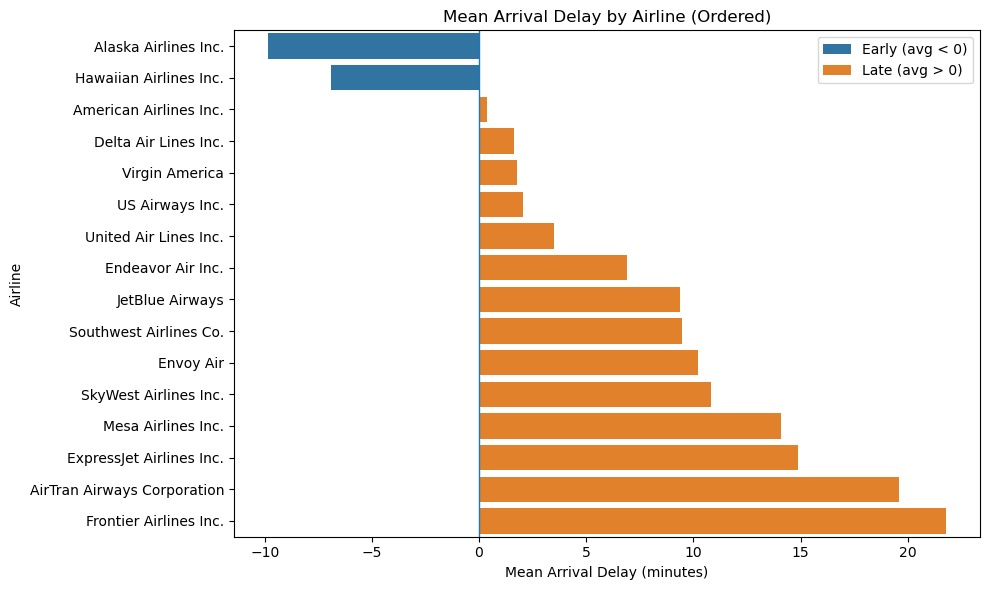

In [144]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.barplot(
    data=delay_df,
    y="airline_name",
    x="mean_delay",
    hue="status",
    dodge=False
)

plt.title("Mean Arrival Delay by Airline (Ordered)")
plt.xlabel("Mean Arrival Delay (minutes)")
plt.ylabel("Airline")
plt.axvline(0, linewidth=1)
plt.legend(title="")
plt.tight_layout()
plt.show()

In [145]:
earliest_airline = delay_df.iloc[0][["airline_name", "mean_delay"]]
earliest_airline

airline_name    Alaska Airlines Inc.
mean_delay                     -9.86
Name: 1, dtype: object